# Итоговый отчёт по ВКР
## Моделирование и визуализация угроз в мобильных P2P-сетях на базе геоданных

**Дата формирования отчёта:** 14 мая 2026  
**Репозиторий:** `vkr-p2p-geothreats`  
**Версия прототипа:** v0.3  

Этот ноутбук автоматически запускает эксперименты, загружает метрики и строит итоговый отчёт.

### 0. Подготовка окружения
Ноутбук можно запускать как из папки `notebooks/`, так и из корня проекта. Пути ниже определяются автоматически.

In [38]:
import os
import sys
import subprocess
from pathlib import Path


def detect_project_root() -> Path:
    """Определяет корень проекта относительно текущей папки Jupyter."""
    cwd = Path.cwd().resolve()
    if cwd.name == "notebooks":
        return cwd.parent
    if (cwd / "notebooks").exists() or (cwd / "src").exists() or (cwd / "outputs").exists():
        return cwd
    return cwd

project_root = detect_project_root()
os.chdir(project_root)

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
if (project_root / "src").exists() and str(project_root / "src") not in sys.path:
    sys.path.insert(0, str(project_root / "src"))

print(f"Project root: {project_root}")
print(f"Python: {sys.executable}")

Project root: /Users/vladimir/Desktop/vkr
Python: /Users/vladimir/Desktop/vkr/venv/bin/python


### 1. Запуск экспериментов
Если итоговые CSV уже есть, повторный запуск не выполняется. Для полной перегенерации удалите папку `outputs/`.

In [37]:
def find_script(name: str) -> Path | None:
    """Ищет скрипт в src/ и в корне проекта."""
    candidates = [project_root / "src" / name, project_root / name]
    return next((p for p in candidates if p.exists()), None)


def run_script(name: str, args: list[str] | None = None, desc: str = "") -> int:
    args = args or []
    script = find_script(name)
    if script is None:
        print(f"[SKIP] Скрипт не найден: {name}")
        return 127
    cmd = [sys.executable, str(script), *args]
    print(f"\n==> {desc or name}")
    print(" ".join(cmd))
    result = subprocess.run(cmd, text=True)
    if result.returncode != 0:
        print(f"[WARNING] Команда завершилась с кодом {result.returncode}")
    return result.returncode

radius_summary = project_root / "outputs" / "tables" / "radius" / "summary_metrics.csv"
knn_summary = project_root / "outputs" / "tables" / "knn" / "summary_metrics.csv"
stability_summary = project_root / "outputs" / "tables" / "stability_metrics.csv"
legacy_summary = project_root / "outputs" / "tables" / "summary_metrics.csv"

need_rerun = not (radius_summary.exists() and knn_summary.exists())

if need_rerun:
    print("CSV для v0.3 не найдены. Пробую запустить эксперименты...")
    rc1 = run_script("run_experiment.py", ["-g", "radius"], "Radius graph experiments")
    rc2 = run_script("run_experiment.py", ["-g", "knn"], "k-NN graph experiments")
    if rc1 != 0 or rc2 != 0:
        print("\n[INFO] Возможно, локальная версия run_experiment.py ещё не поддерживает -g. Пробую legacy-запуск без аргументов.")
        run_script("run_experiment.py", [], "Legacy experiments")
    if find_script("run_multi_seed.py") is not None:
        run_script("run_multi_seed.py", ["--runs", "10"], "Stability runs")
    else:
        print("[SKIP] run_multi_seed.py не найден — блок устойчивости будет пропущен, если CSV отсутствует.")
else:
    print("Файлы с данными уже существуют. Запуск экспериментов пропущен.")

print("\nГотово к построению отчёта.")

Файлы с данными уже существуют. Запуск экспериментов пропущен.

Готово к построению отчёта.


### 2. Импорт библиотек и загрузка данных

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", "{:.4f}".format)


def read_csv_first_existing(*paths: Path, index_col=None) -> pd.DataFrame:
    for path in paths:
        if path.exists():
            print(f"Loaded: {path.relative_to(project_root)}")
            return pd.read_csv(path, index_col=index_col)
    existing = sorted((project_root / "outputs" / "tables").glob("**/*.csv")) if (project_root / "outputs" / "tables").exists() else []
    raise FileNotFoundError(
        "Не найден ни один из файлов:\n" +
        "\n".join(str(p) for p in paths) +
        "\n\nДоступные CSV:\n" + "\n".join(str(p.relative_to(project_root)) for p in existing)
    )

# v0.3: отдельные папки radius/knn. Legacy fallback: outputs/tables/summary_metrics.csv.
df_radius = read_csv_first_existing(radius_summary, legacy_summary, index_col=0)

try:
    df_knn = read_csv_first_existing(knn_summary, index_col=0)
except FileNotFoundError as e:
    print("[WARNING] k-NN CSV не найден. Будет использован пустой блок, пока не добавлен k-NN запуск.")
    df_knn = pd.DataFrame()

try:
    stability = read_csv_first_existing(stability_summary)
except FileNotFoundError:
    print("[WARNING] stability_metrics.csv не найден. Блок устойчивости будет пропущен.")
    stability = pd.DataFrame()

print("\nЗагрузка данных завершена.")

Loaded: outputs/tables/radius/summary_metrics.csv
Loaded: outputs/tables/knn/summary_metrics.csv
Loaded: outputs/tables/stability_metrics.csv

Загрузка данных завершена.


### 3. Сводка метрик: Radius Graph

In [30]:
display(Markdown("**Таблица 3.1 — Сравнение метрик до и после воздействия угроз (Radius Graph)**"))
display(df_radius)

**Таблица 3.1 — Сравнение метрик до и после воздействия угроз (Radius Graph)**

,Baseline,Rogue,Flooding,Isolation,Spoofing
nodes,50.0000,50.0000,50.0000,50.0000,51.0000
edges,82.0000,96.0000,82.0000,77.0000,87.0000
density,0.0669,0.0784,0.0669,0.0629,0.0682
avg_degree,3.2800,3.8400,3.2800,3.0800,3.4118
num_components,7.0000,3.0000,7.0000,10.0000,6.0000
largest_component_size,34.0000,41.0000,34.0000,18.0000,38.0000
isolated_nodes,2.0000,0.0000,2.0000,4.0000,2.0000
avg_clustering,0.5169,0.6065,0.5169,0.4609,0.4832
max_degree_centrality,0.1633,0.2857,0.1633,0.1633,0.1600
max_betweenness_centrality,0.2568,0.4413,0.2568,0.0408,0.2629


### 4. Сводка метрик: k-NN Graph

In [31]:
if not df_knn.empty:
    display(Markdown("**Таблица 3.2 — Сравнение метрик до и после воздействия угроз (k-NN Graph)**"))
    display(df_knn)
else:
    display(Markdown("**k-NN Graph:** данные пока отсутствуют. Нужно запустить/добавить генерацию `outputs/tables/knn/summary_metrics.csv`."))

**Таблица 3.2 — Сравнение метрик до и после воздействия угроз (k-NN Graph)**

,Baseline,Rogue,Flooding,Isolation,Spoofing
nodes,50.0000,50.0000,50.0000,50.0000,51.0000
edges,150.0000,159.0000,150.0000,132.0000,155.0000
density,0.1224,0.1298,0.1224,0.1078,0.1216
avg_degree,6.0000,6.3600,6.0000,5.2800,6.0784
num_components,1.0000,1.0000,1.0000,4.0000,1.0000
largest_component_size,50.0000,50.0000,50.0000,47.0000,51.0000
isolated_nodes,0.0000,0.0000,0.0000,3.0000,0.0000
avg_clustering,0.6373,0.6523,0.6373,0.5978,0.6094
max_degree_centrality,0.1837,0.2857,0.1837,0.1837,0.1800
max_betweenness_centrality,0.2641,0.2581,0.2641,0.2216,0.2320


### 5. Визуализация графов для Radius Graph

**Рис. baseline (radius): после угрозы**

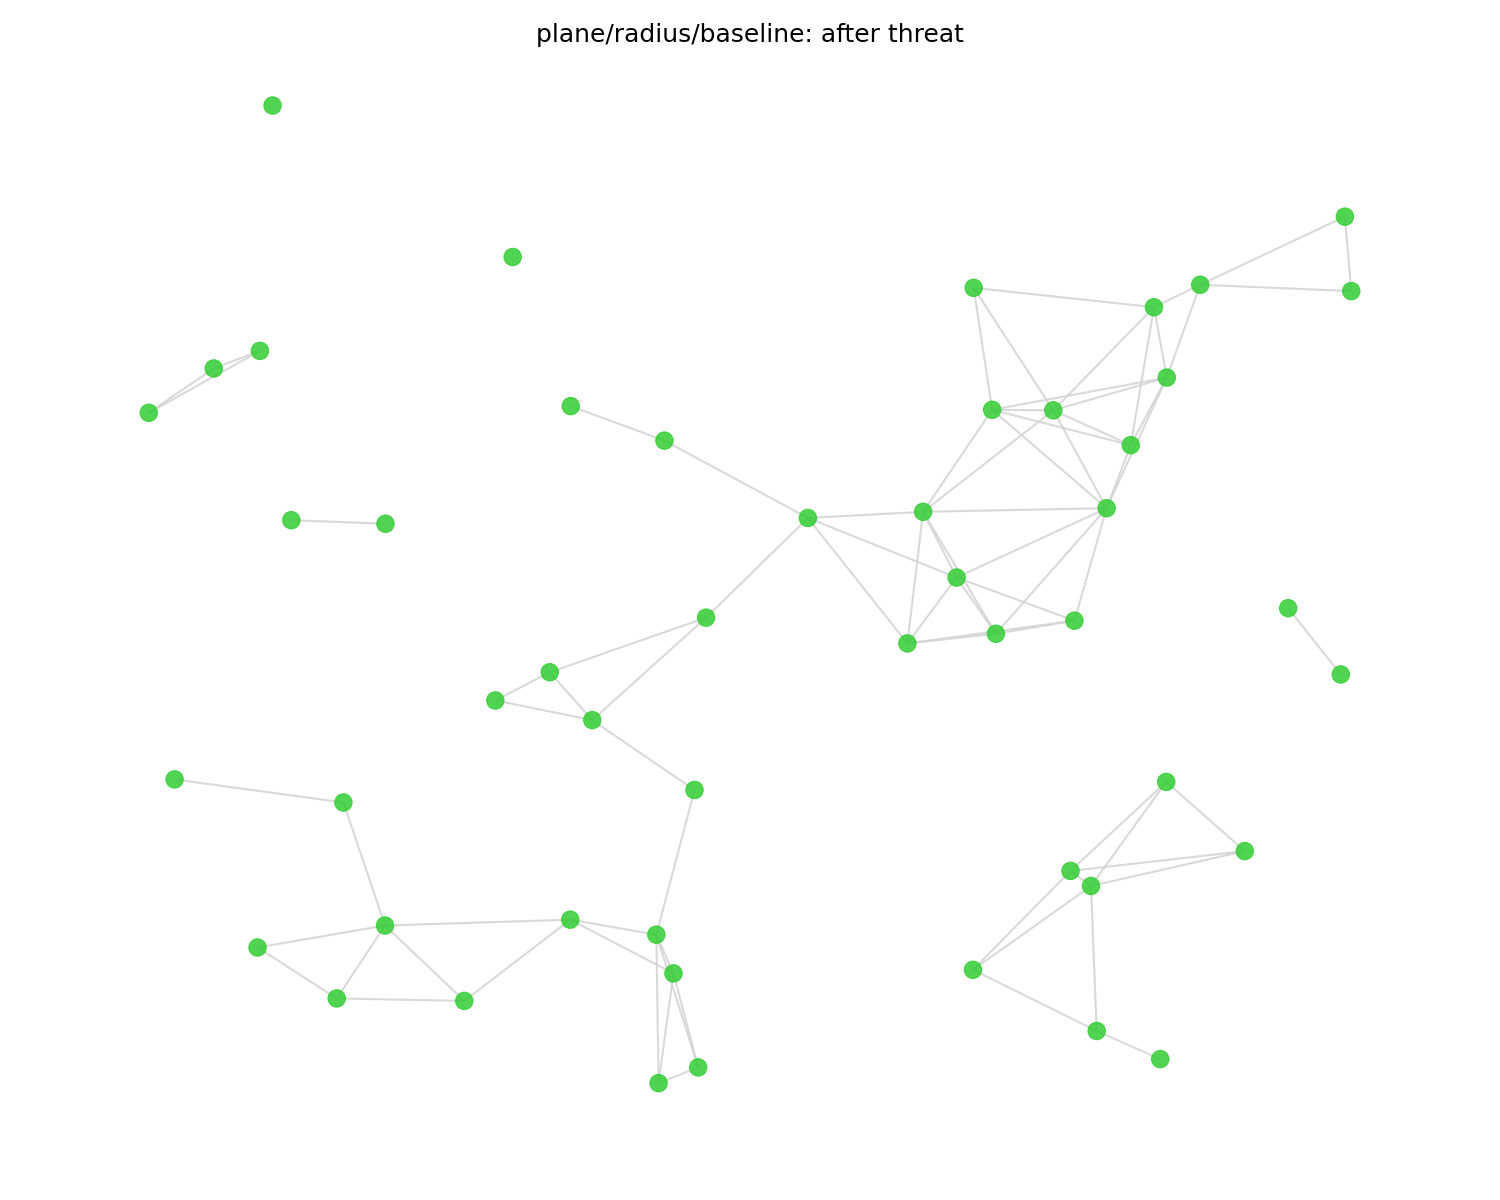

**Рис. rogue (radius): после угрозы**

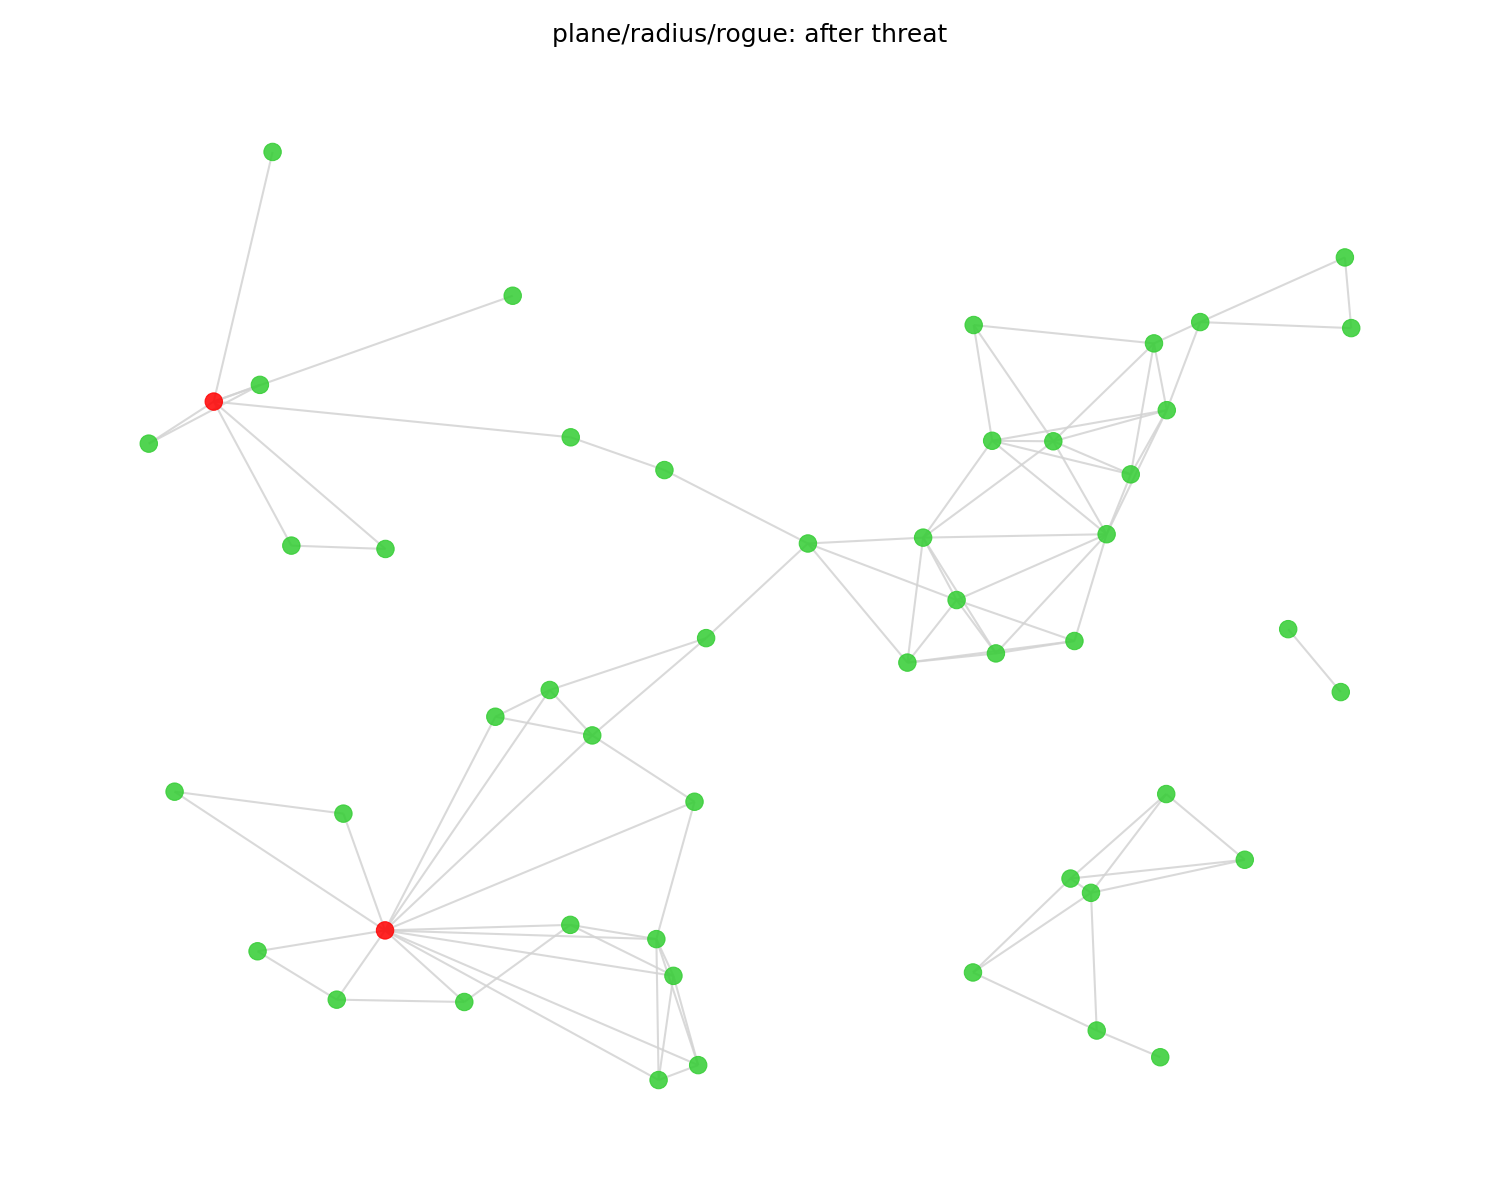

**Рис. flooding (radius): после угрозы**

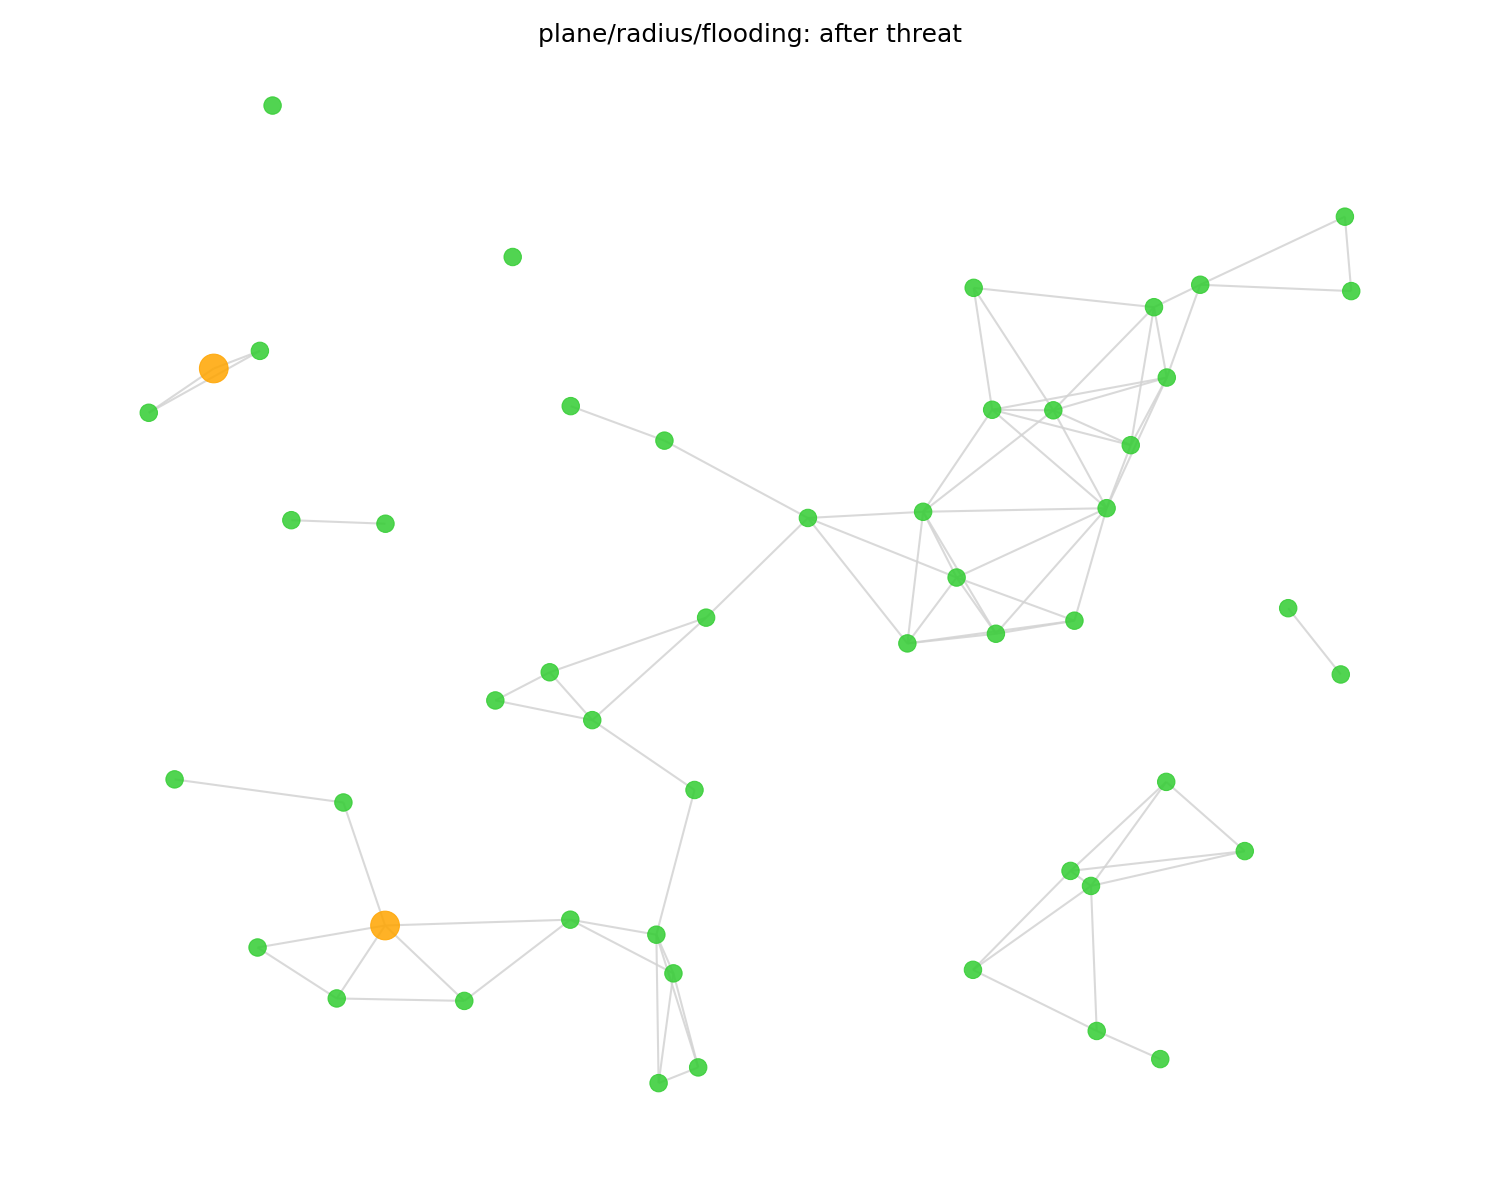

**Рис. isolation (radius): после угрозы**

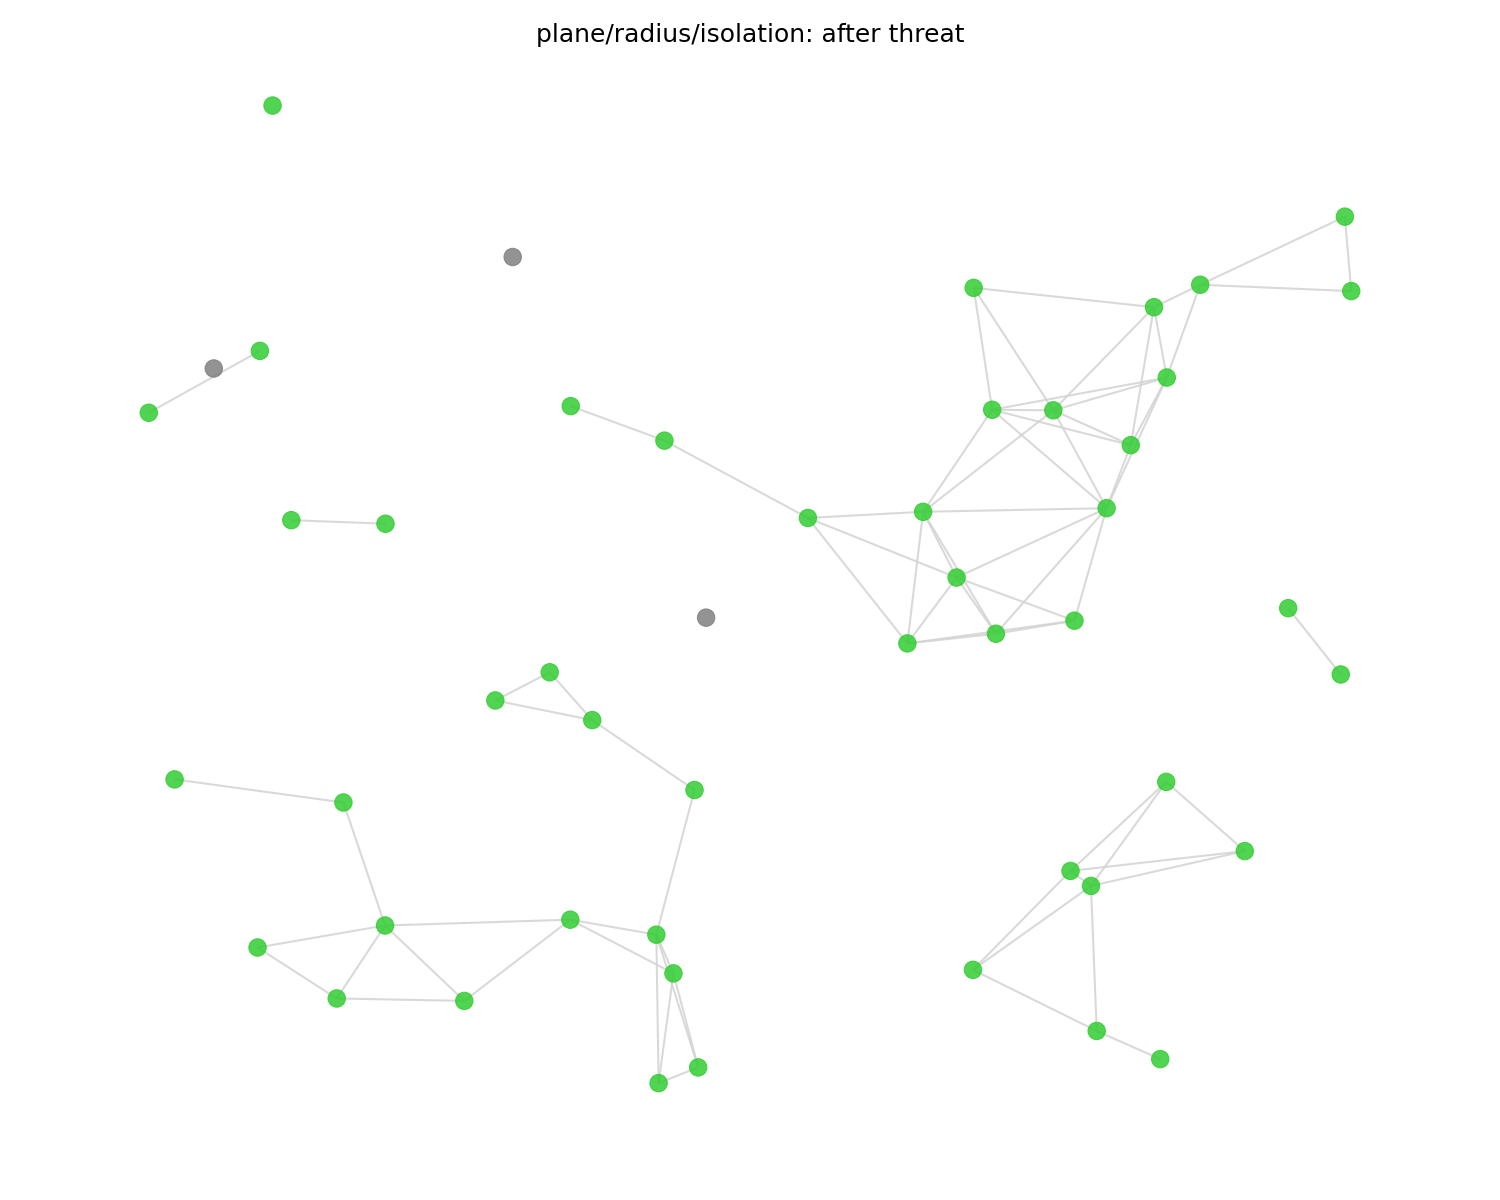

**Рис. spoofing (radius): после угрозы**

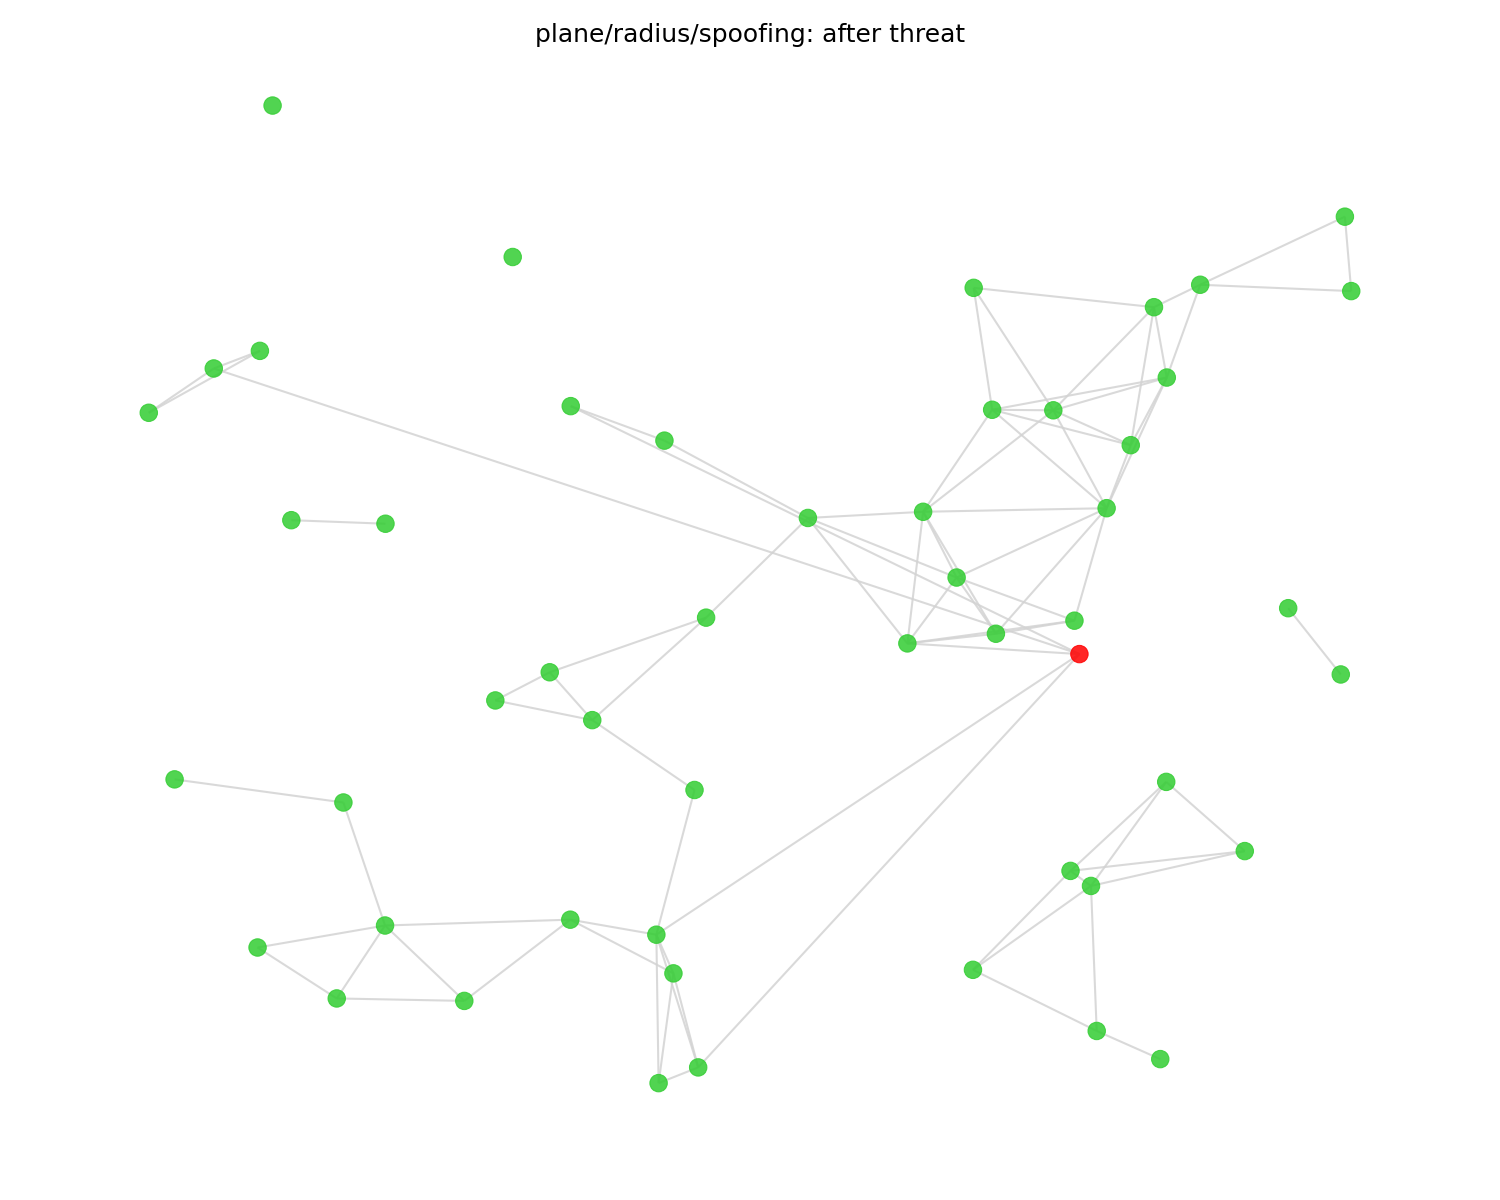

In [32]:
scenarios = ["baseline", "rogue", "flooding", "isolation", "spoofing"]

for scen in scenarios:
    candidates = [
        project_root / "outputs" / "figures" / "radius" / f"{scen}_after.png",
        project_root / "outputs" / "figures" / f"{scen}_after.png",  # legacy fallback
    ]
    img = next((p for p in candidates if p.exists()), None)
    if img is not None:
        display(Markdown(f"**Рис. {scen} (radius): после угрозы**"))
        display(Image(str(img), width=600))
    else:
        print(f"Файл не найден для сценария radius/{scen}: {[str(p.relative_to(project_root)) for p in candidates]}")

### 6. Визуализация графов для k-NN Graph

**Рис. baseline (k-NN): после угрозы**

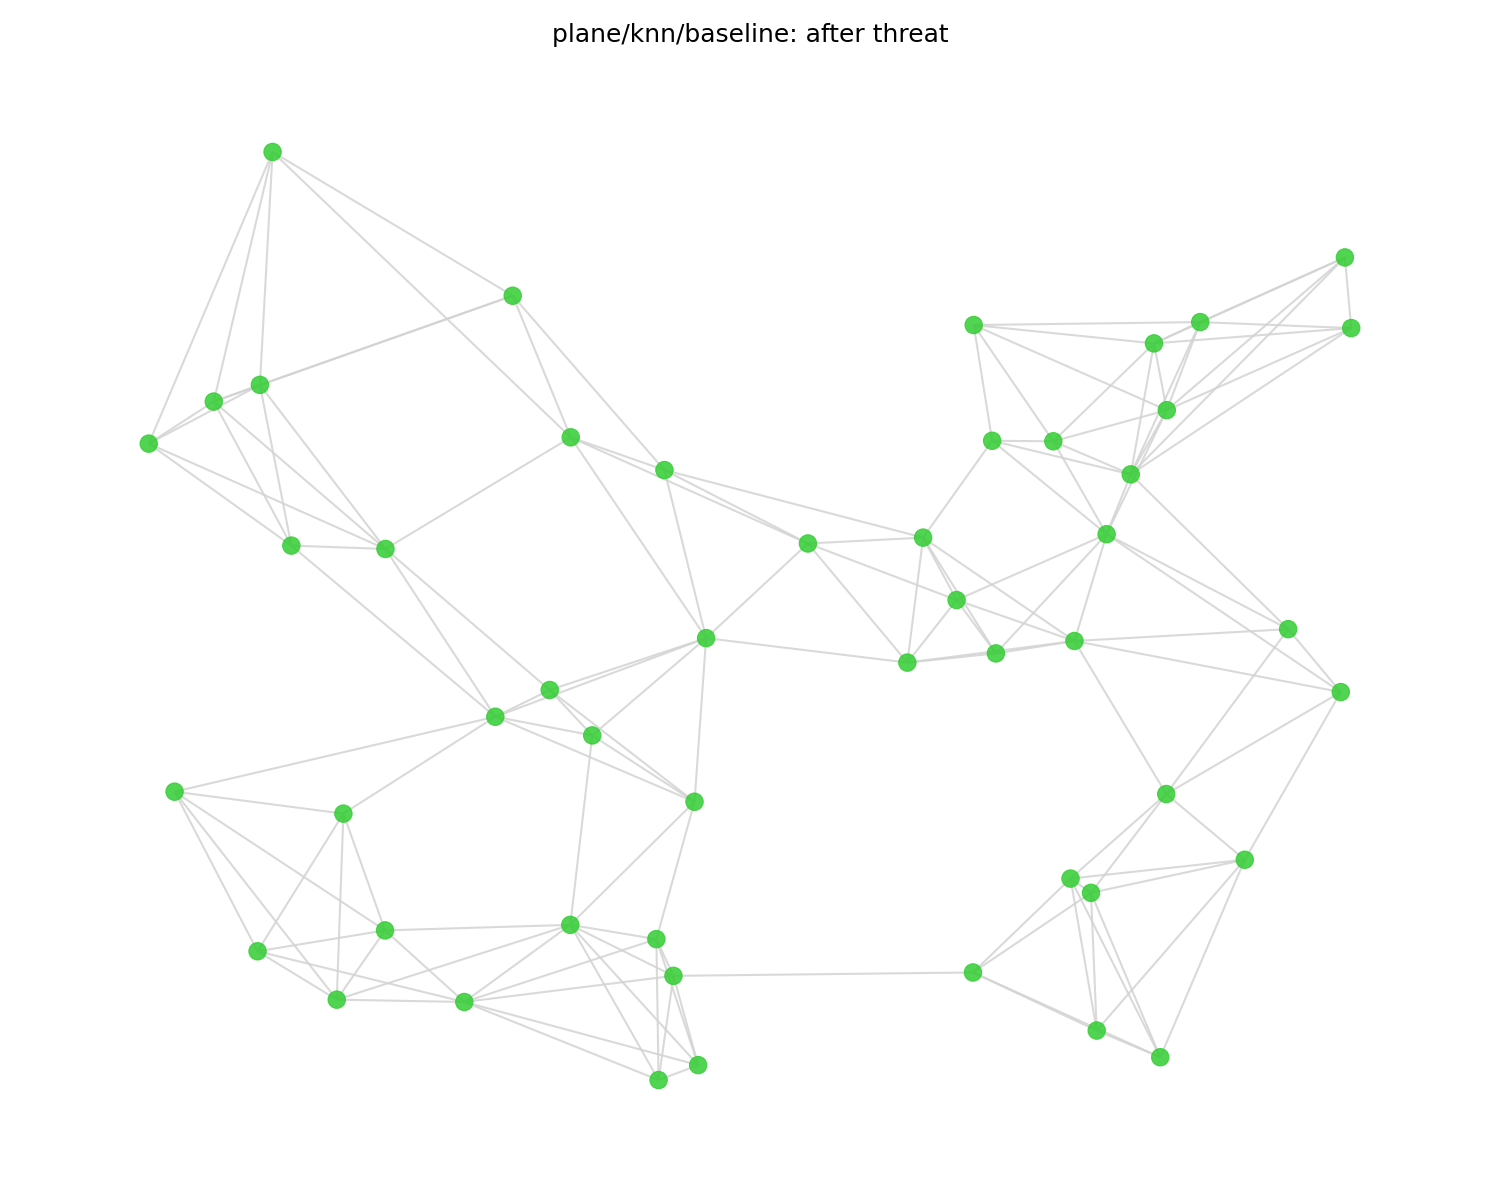

**Рис. rogue (k-NN): после угрозы**

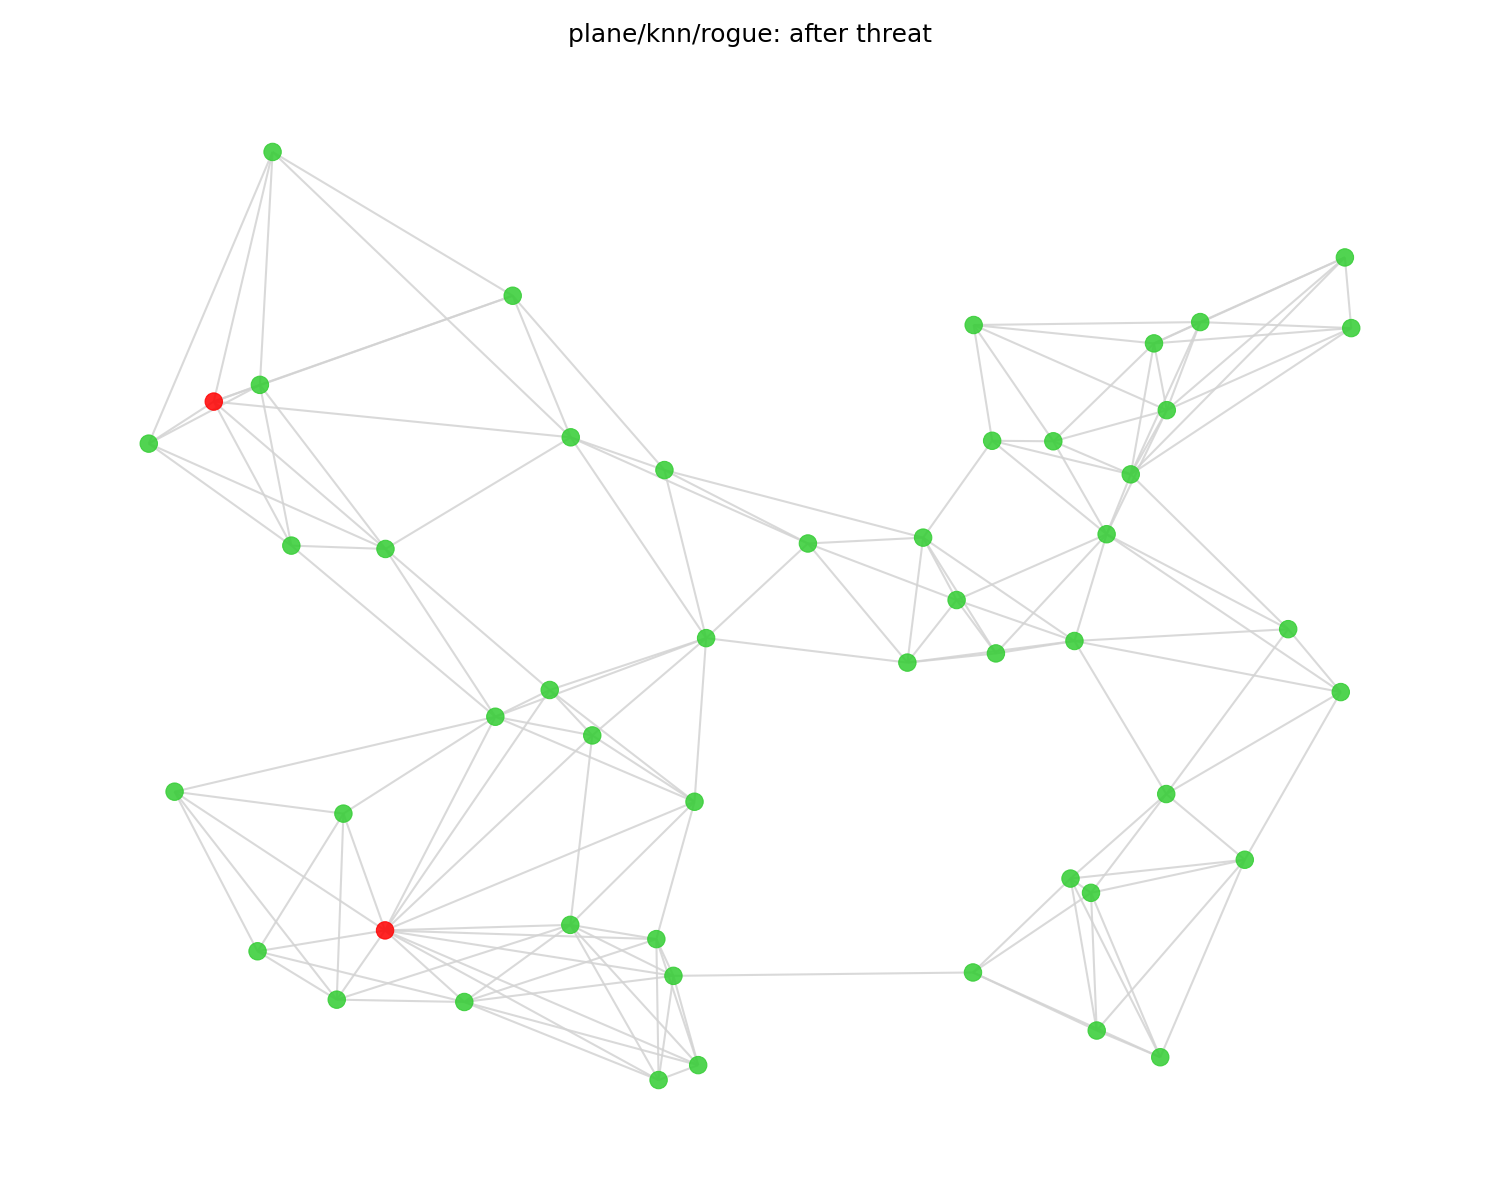

**Рис. flooding (k-NN): после угрозы**

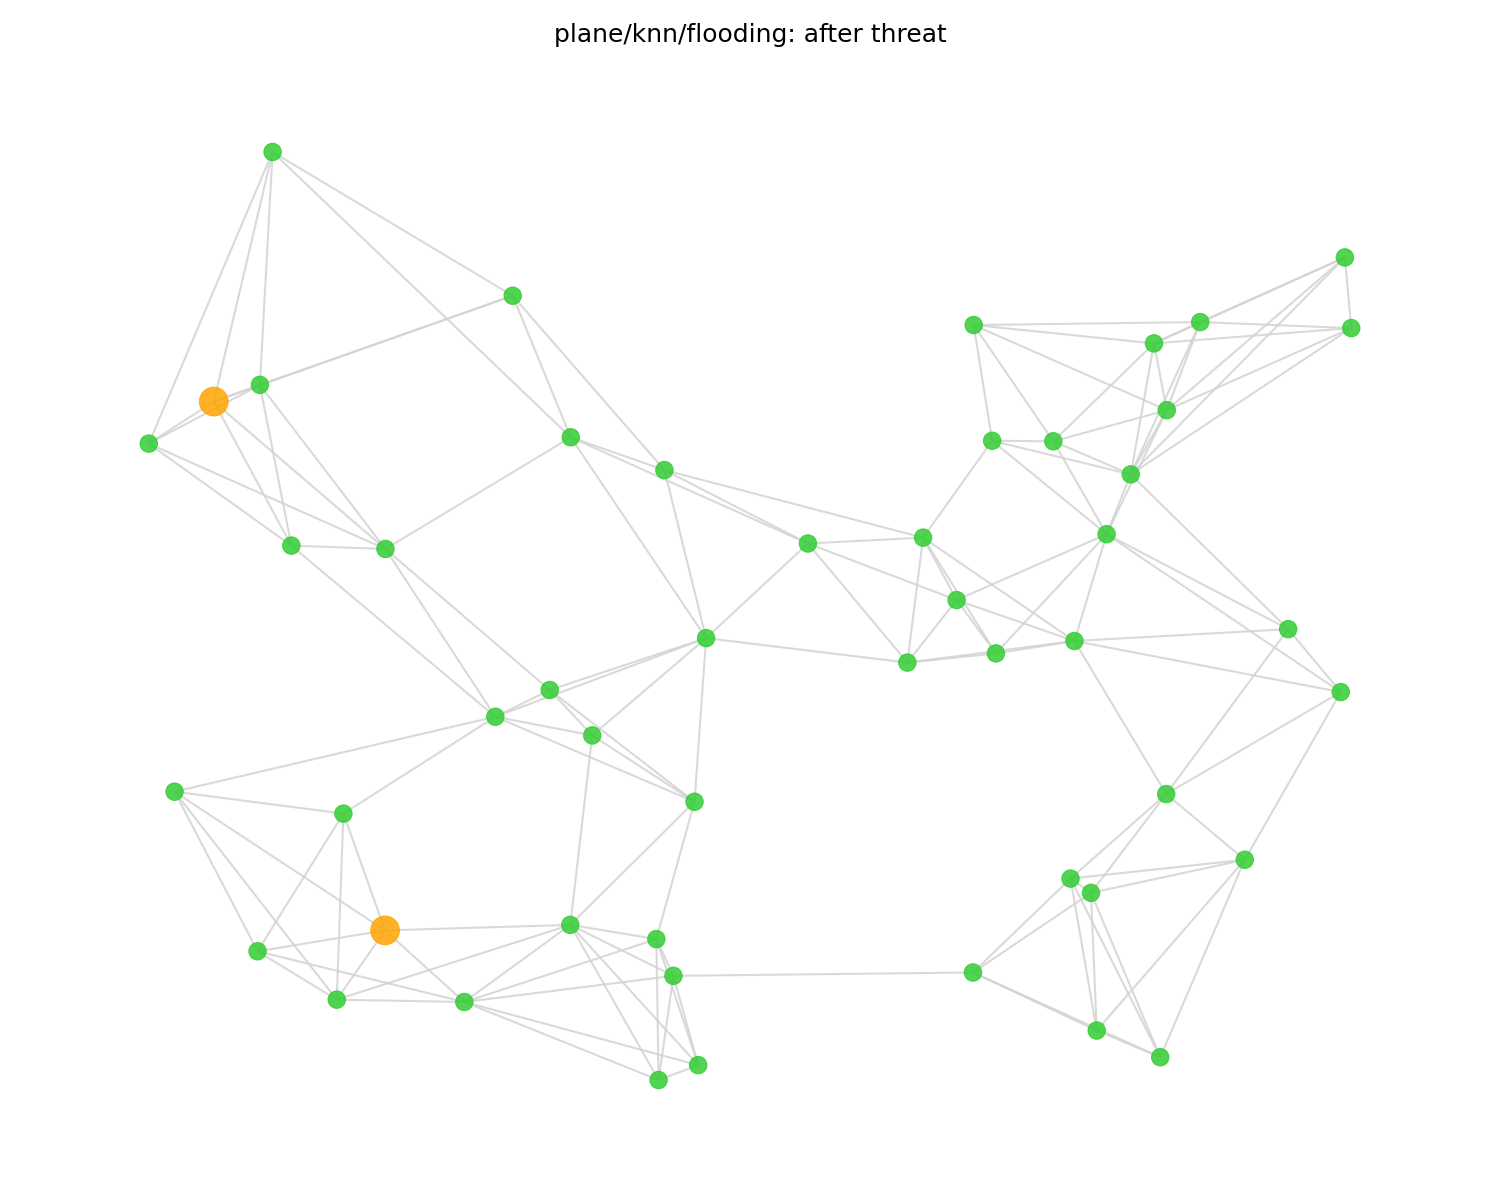

**Рис. isolation (k-NN): после угрозы**

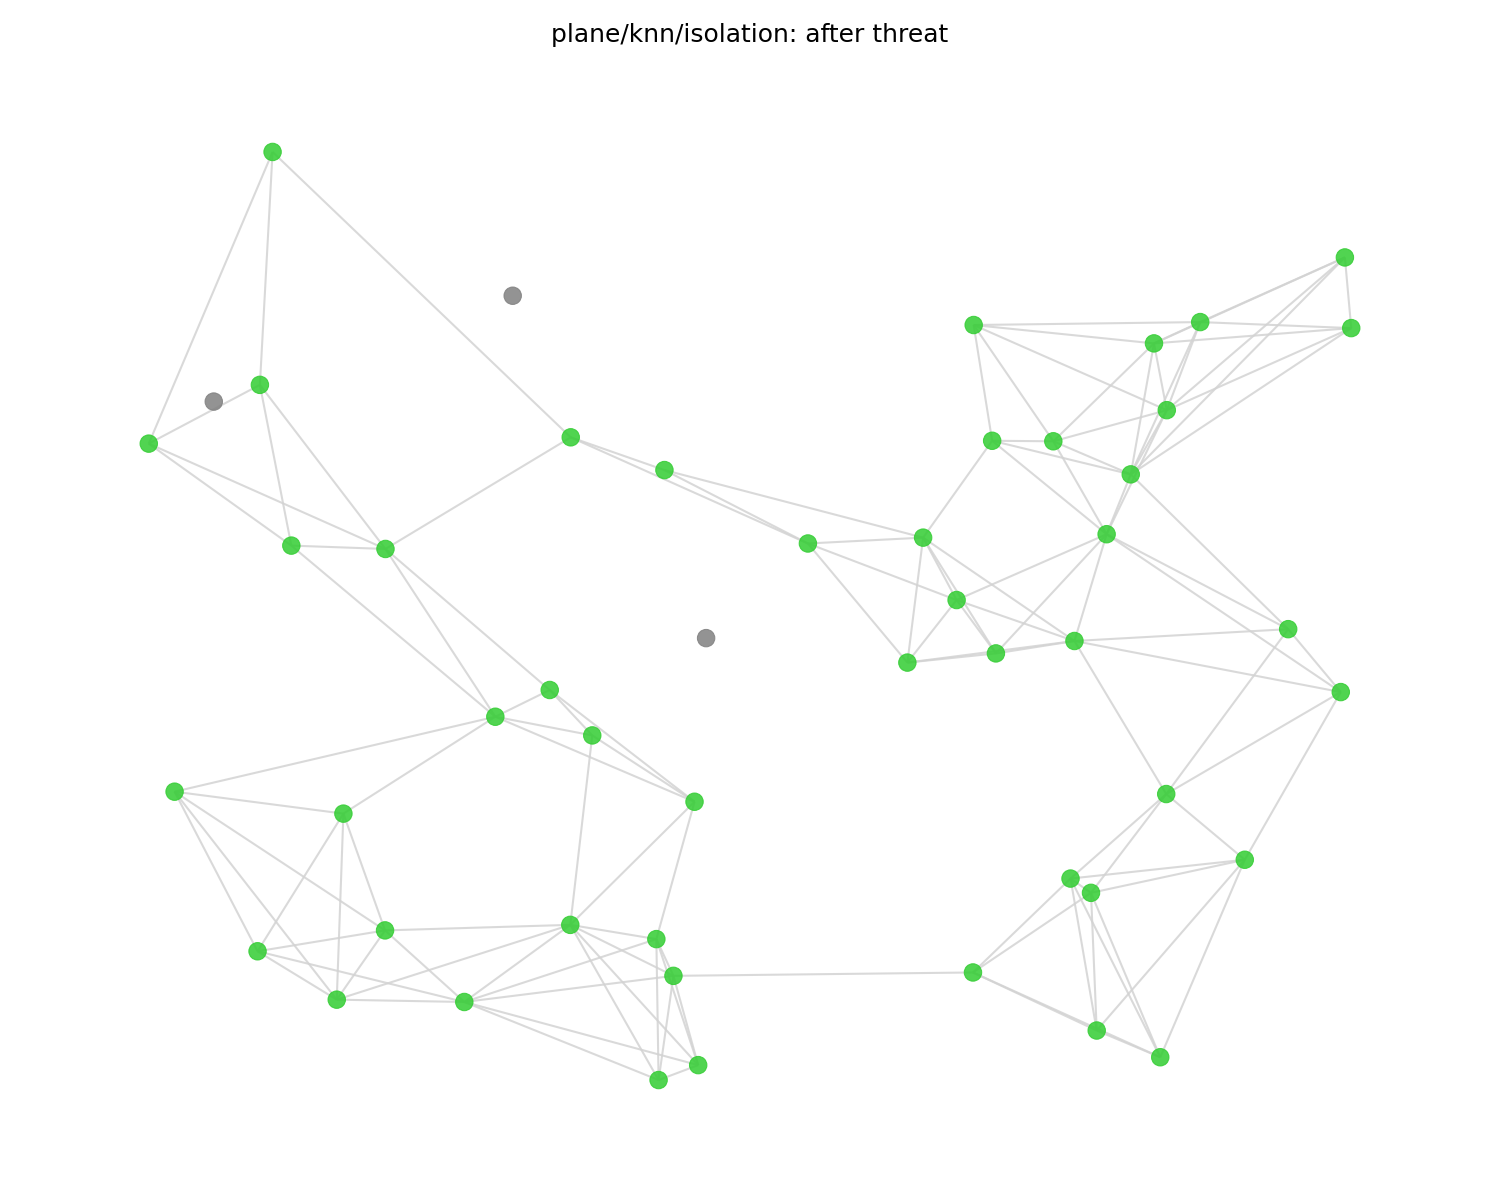

**Рис. spoofing (k-NN): после угрозы**

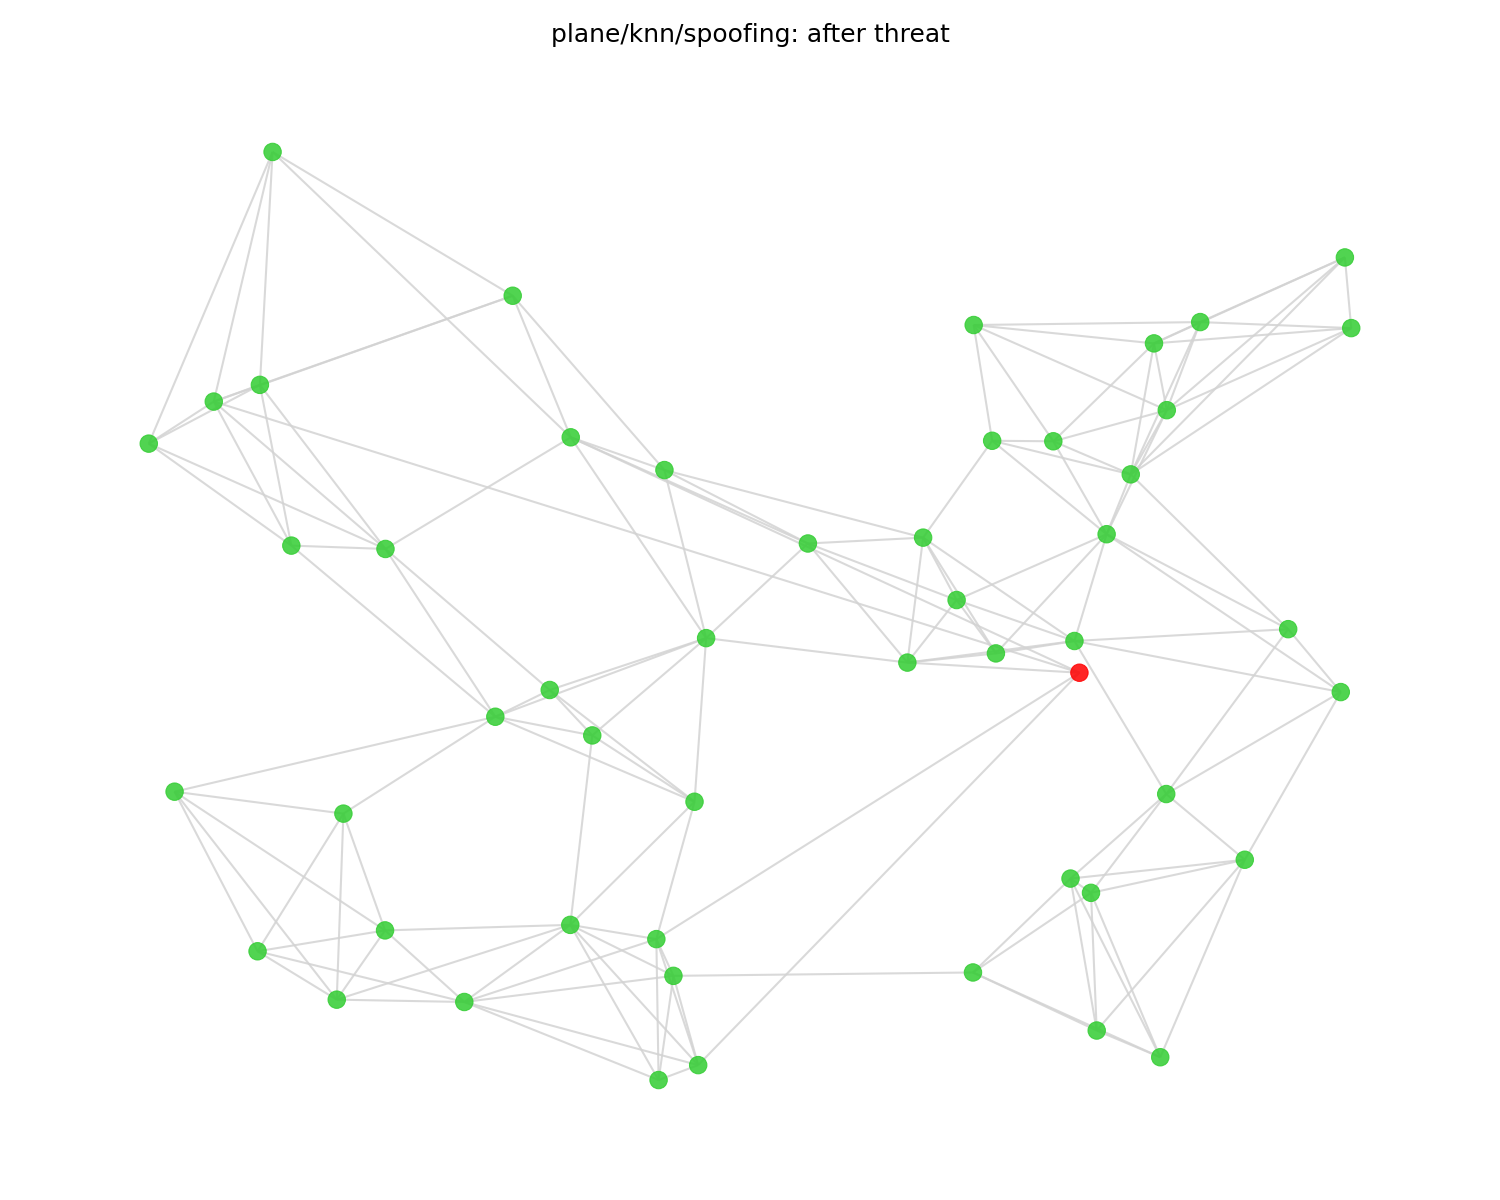

In [33]:
for scen in scenarios:
    img = project_root / "outputs" / "figures" / "knn" / f"{scen}_after.png"
    if img.exists():
        display(Markdown(f"**Рис. {scen} (k-NN): после угрозы**"))
        display(Image(str(img), width=600))
    else:
        print(f"Файл не найден: {img.relative_to(project_root)}")

### 7. Таблица устойчивости

In [34]:
if not stability.empty:
    display(Markdown("**Таблица 3.3 — Устойчивость метрик при различных начальных условиях (mean ± std)**"))
    preferred = [
        "scenario", "graph_type", "nodes_mean", "edges_mean", "density_mean", "avg_degree_mean",
        "num_components_mean", "largest_component_size_mean", "isolated_nodes_mean",
        "max_degree_centrality_mean", "max_betweenness_centrality_mean",
        "total_load_mean", "load_anomaly_count_mean"
    ]
    cols = [c for c in preferred if c in stability.columns]
    display(stability[cols] if cols else stability)
else:
    display(Markdown("**Устойчивость:** CSV отсутствует. Блок активируется после генерации `outputs/tables/stability_metrics.csv`."))

**Таблица 3.3 — Устойчивость метрик при различных начальных условиях (mean ± std)**

,scenario,graph_type,nodes_mean,edges_mean,density_mean,avg_degree_mean,num_components_mean,largest_component_size_mean,isolated_nodes_mean,max_degree_centrality_mean,max_betweenness_centrality_mean,total_load_mean,load_anomaly_count_mean
0,baseline,radius,50.0000,72.5000,0.0592,2.9000,8.4000,23.9000,2.7000,0.1388,0.1090,0.0000,0.0000
1,rogue,radius,50.0000,86.8000,0.0709,3.4720,5.8000,32.4000,1.4000,0.2429,0.2542,0.0000,0.0000
2,flooding,radius,50.0000,72.5000,0.0592,2.9000,8.4000,23.9000,2.7000,0.1388,0.1090,20.0000,2.0000
3,isolation,radius,50.0000,65.7000,0.0536,2.6280,11.6000,21.4000,6.2000,0.1327,0.0825,0.0000,0.0000
4,spoofing,radius,51.0000,77.5000,0.0608,3.0392,6.1000,35.0000,2.3000,0.1420,0.2693,0.0000,0.0000
5,baseline,knn,50.0000,151.2000,0.1234,6.0480,1.0000,50.0000,0.0000,0.2000,0.2456,0.0000,0.0000
6,rogue,knn,50.0000,159.0000,0.1298,6.3600,1.0000,50.0000,0.0000,0.2510,0.2780,0.0000,0.0000
7,flooding,knn,50.0000,151.2000,0.1234,6.0480,1.0000,50.0000,0.0000,0.2000,0.2456,20.0000,2.0000
8,isolation,knn,50.0000,134.2000,0.1096,5.3680,4.0000,47.0000,3.0000,0.1918,0.2489,0.0000,0.0000
9,spoofing,knn,51.0000,156.2000,0.1225,6.1255,1.0000,51.0000,0.0000,0.1980,0.2394,0.0000,0.0000


### 8. Боксплоты устойчивости

**Рис. Боксплоты распределения ключевых метрик**

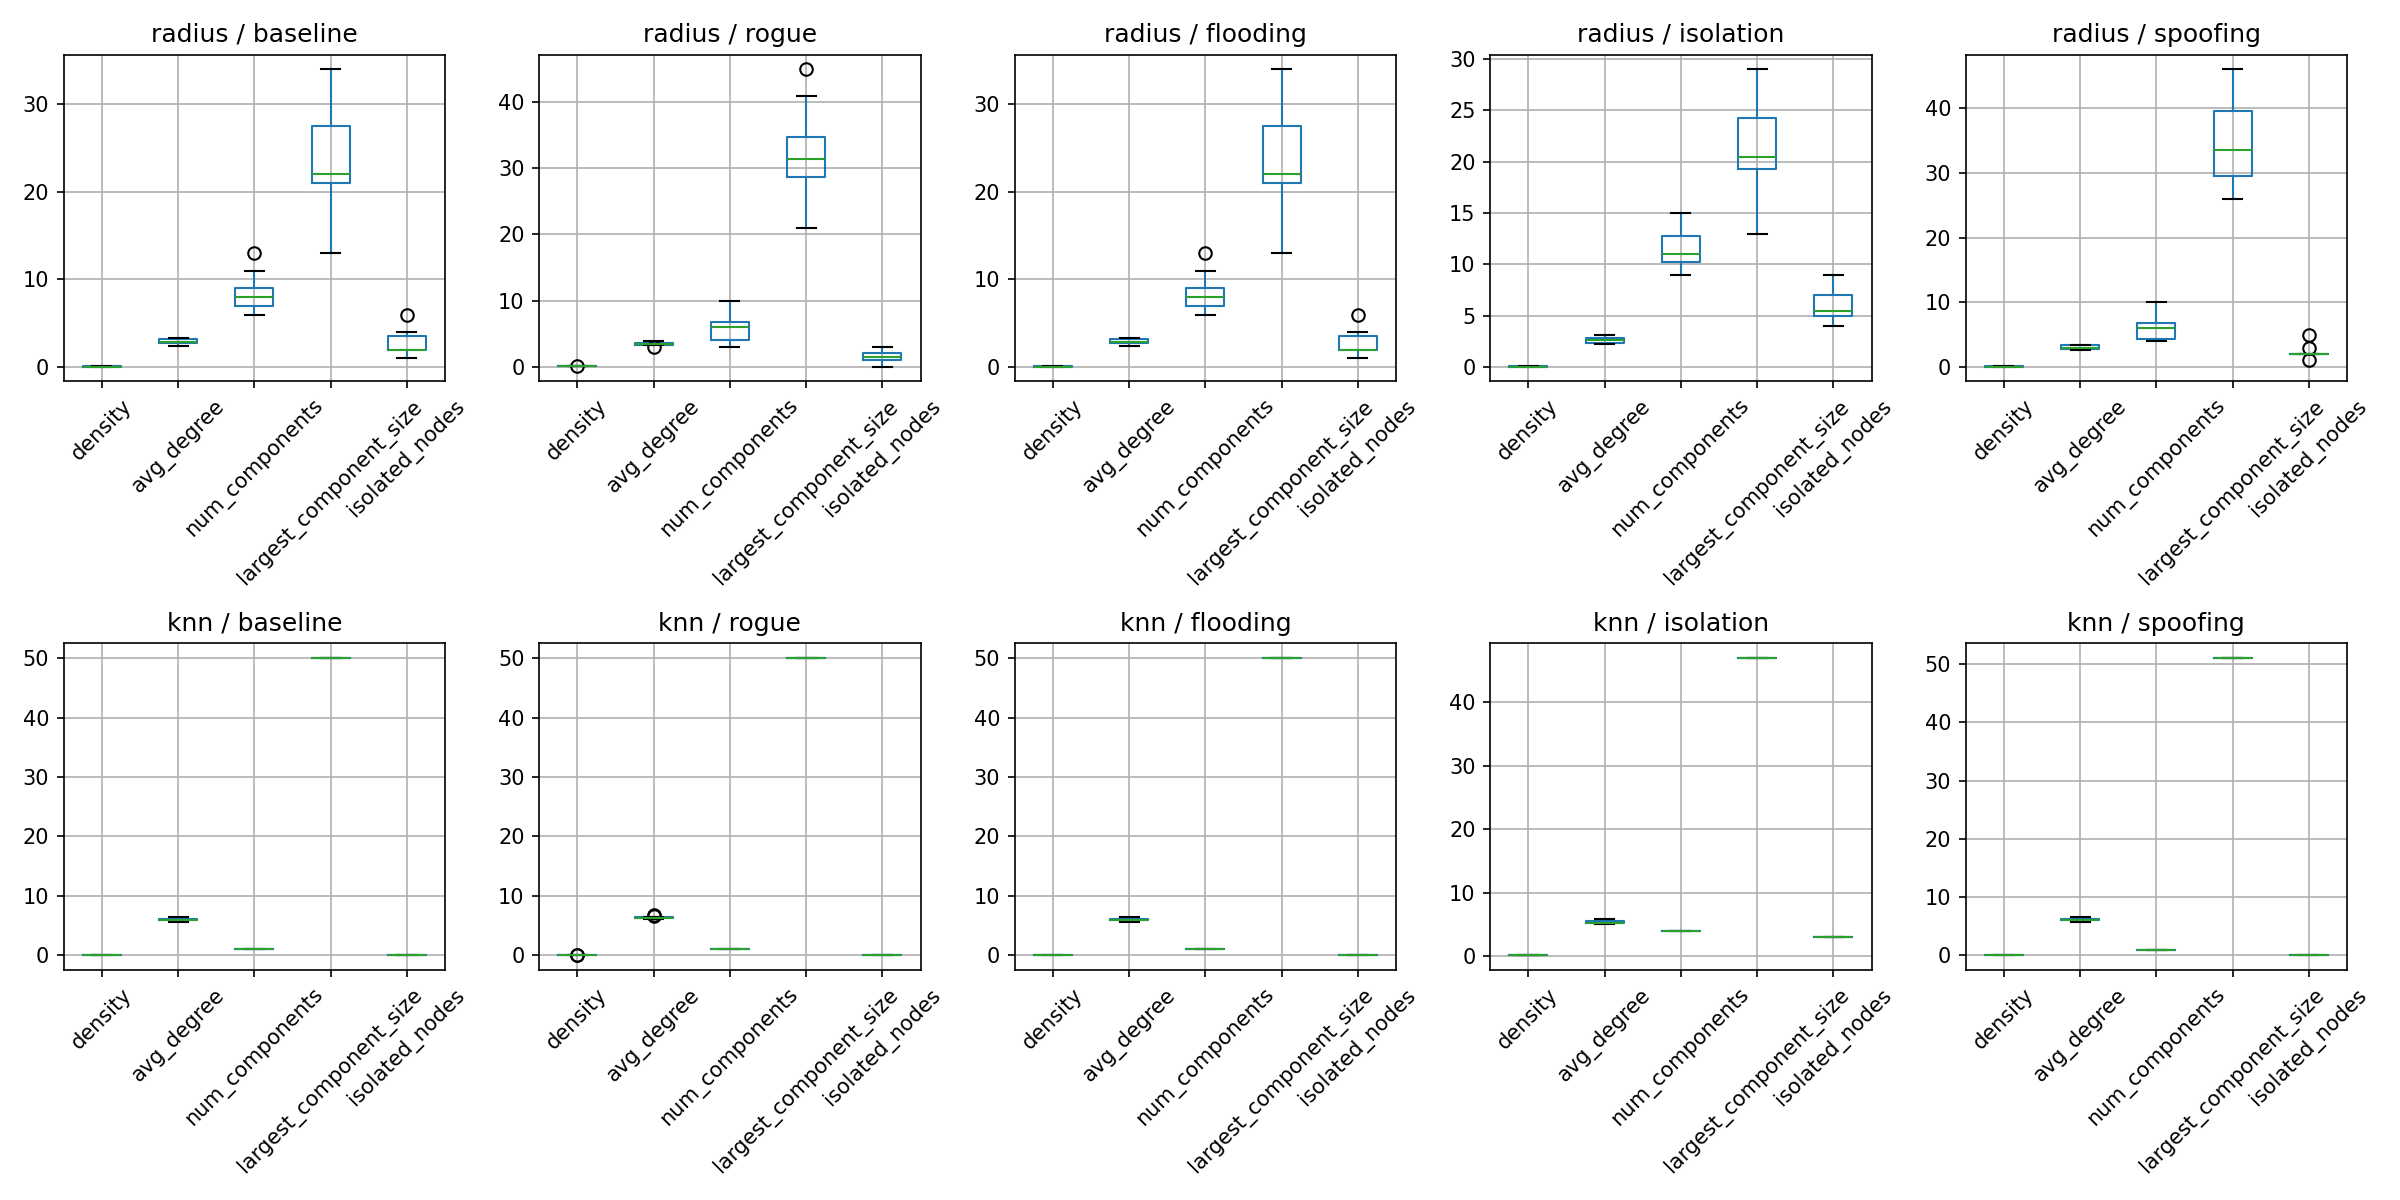

In [35]:
boxplot_path = project_root / "outputs" / "figures" / "stability_boxplots.png"
if boxplot_path.exists():
    display(Markdown("**Рис. Боксплоты распределения ключевых метрик**"))
    display(Image(str(boxplot_path), width=900))
else:
    print(f"Файл не найден: {boxplot_path.relative_to(project_root)}")

### 9. Сравнительный анализ: Radius vs. k-NN

In [36]:
def get_metric(df: pd.DataFrame, column: str, metric: str):
    if df.empty or column not in df.columns or metric not in df.index:
        return "—"
    return df.loc[metric, column]

comparison = pd.DataFrame({
    "Метрика": ["Рёбер (baseline)", "Компонент связности", "Изолированных узлов", "Плотность", "Средняя степень"],
    "Radius Graph": [
        get_metric(df_radius, "Baseline", "edges"),
        get_metric(df_radius, "Baseline", "num_components"),
        get_metric(df_radius, "Baseline", "isolated_nodes"),
        get_metric(df_radius, "Baseline", "density"),
        get_metric(df_radius, "Baseline", "avg_degree"),
    ],
    "k-NN Graph": [
        get_metric(df_knn, "Baseline", "edges"),
        get_metric(df_knn, "Baseline", "num_components"),
        get_metric(df_knn, "Baseline", "isolated_nodes"),
        get_metric(df_knn, "Baseline", "density"),
        get_metric(df_knn, "Baseline", "avg_degree"),
    ],
})

display(Markdown("**Таблица 3.4 — Сравнение базовых метрик двух типов графов**"))
display(comparison)

**Таблица 3.4 — Сравнение базовых метрик двух типов графов**

,Метрика,Radius Graph,k-NN Graph
0,Рёбер (baseline),82.0000,150.0000
1,Компонент связности,7.0000,1.0000
2,Изолированных узлов,2.0000,0.0000
3,Плотность,0.0669,0.1224
4,Средняя степень,3.2800,6.0000


### 10. Выводы

1. **Radius graph** используется как модель физической/радиусной доступности узлов и показывает чувствительность сети к изменению пространственной близости.
2. **k-NN graph** используется как альтернативная модель связности: он позволяет сравнить пессимистичный и более связный вариант топологии.
3. **Flooding** может слабо менять структуру графа, но должен проявляться через нагрузочные метрики.
4. **Isolation** проверяет устойчивость связности и размер крупнейшей компоненты.
5. **Rogue/spoofing** полезны для анализа появления подозрительно влиятельных узлов и аномальных связей.
6. Совместное использование radius и k-NN даёт более убедимую экспериментальную базу для ВКР, чем один тип графа.